In [ ]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem

from rdkit.Chem import Draw



In [ ]:
"""wd_Path = "/Users/dylan/Documents/chemical_screen/"
df1 = pd.read_excel(wd_Path + "20251020_Run15_Report.xlsx", sheet_name = "CDD Export 1")
df2 = pd.read_excel(wd_Path + "20251027_Run16_Report.xlsx",  sheet_name = "CDD Export 1")
df3 = pd.read_excel(wd_Path + "20251105_Run17_Report.xlsx",  sheet_name = "CDD Export 1")
df4 = pd.read_excel(wd_Path + "20251110_Run18_Report.xlsx",  sheet_name = "CDD Export 1")
df5 = pd.read_excel(wd_Path + "20251117_Run19_Report.xlsx",  sheet_name = "CDD Export 1")
df5
df = pd.concat([df1,df2,df3,df4,df5], ignore_index = True)
df = df.iloc[:, 0:21] """
import sys


wd_Path = "/Users/dylan/Downloads/"
df = pd.read_excel(wd_Path + "CondenScreenV2.xlsx", sheet_name = "Combined Analysis")
print(sys.executable)




In [114]:
df
sub_df = df[['Reference', 'SMILES', 'BZScore', 'tdTomato_Diff', 'Viability', 'Plate', 'Well', 'Normalized_Effect']]

sub_df

,Reference,SMILES,BZScore,tdTomato_Diff,Viability,Plate,Well,Normalized_Effect
0,Y-0209987,O=C(N1[C@H](C2=CN(C)N=C2)CCC1)C1=CC(C)=NC2=CC=...,11.97,-95.07,0.03,A21049,C03,99.99
1,Y-0209876,O1C(C)CN(C2=NC=C(CNC3C(C)(C)C(OCC)C3)C=C2)CC1,11.26,-86.48,-4.85,A21048,C16,100.00
2,Y-0218023,S(=O)(=O)(N(C1=NC(OC)=CC=C1)C)C1=CN(CC2=CC=CC=...,10.38,-3.64,-87.42,A21093,B06,72.61
3,Y-0219258,O=C1N(C2CCCC2)CC(C(=O)C(C#N)C(=O)NCC2=CC=CC=C2)C1,10.15,-86.13,-4.24,A21097,K03,99.96
4,Y-0216766,O=C(N1CCN(C2=C(OC)C=CC=C2)CC1)C1=C(OCC)N=CC=C1,9.69,4.86,-91.76,A21088,M07,84.10
...,...,...,...,...,...,...,...,...
203,Y-0221627,ClC1=C(NC(=O)CN2[C@H](C3=C(C)NN=C3C)COCC2)C=CC=C1,2.01,-5.63,2.59,A21119,M11,14.22
204,Y-0210499,ClC1=C([C@@](O)(CNC(=O)NCC2=C(C)N=CS2)C)C=CC=C1,2.00,-20.85,3.24,A21050,F15,11.77
205,Y-0215736,S1C=NC(CN2CCN(C(=O)NCCCC3=CC=CC=C3)CC2)=C1,2.00,44.78,27.62,A21074,O03,15.06
206,Y-0215868,O=C1N(CC2=CC=C(OC)C=C2)C[C@@H](C(=O)NC2(C#N)CC...,2.00,-13.22,7.90,A21075,F11,10.86


In [115]:

#selct only those with >20% effect:
df_BZ = df[df["BZScore"] >= 2 ]

df_Effect = df_BZ[df_BZ["Normalized_Effect"] >= 25 ]

#Select only those with >75% tdTomato:
df_Effect_tdTomato = df_Effect[df_Effect["tdTomato_Diff"] >= -25]
df_Effect_tdTomato

#Select Viability over 75%:
df_Effect_tdTomato_Viability = df_Effect_tdTomato[df_Effect_tdTomato["Viability"] >= -25]
df_Effect_tdTomato_Viability 


SMILES_list = df_Effect_tdTomato_Viability["SMILES"].to_list()
SMILES_list

['S1C2=C(N3CCN(CCCC4=CN(C)N=C4)CC3)N=CN=C2C=C1',
 'BrC1=C(OC)C=CC([C@@H](NCC2=NOC(C)=N2)C)=C1',
 'S1C(C)=NC(CN2CCC(CNC(=O)NC3=CC=CC=C3)CC2)=C1',
 'N1=C(N2CCCCC2)C(CNCC2=C(N(C)C)N(C)N=C2C)=CC=C1',
 'O=C(N(CC1=CN=CC=C1)C)C1=CC(OC)=C(OC2CCCC2)C=C1',
 'O=C(N1CC(N2CCCC2)CCCC1)NC(CC1=CC=C(O)C=C1)C',
 'N1=C(C(C)C)C(CN[C@H](CN2C=NC=C2)C)=C(N(C)C)N1C',
 'S1C(N(C(=O)C)C)=NC(CN2[C@H](C3=C(C)N(C)N=C3C)CCC2)=C1',
 'FC(F)(F)CN1CCN(CC(=O)NC2=CC(OC)=CC=C2)CCC1',
 'O=C(N(CCN(C1CCN(C)CC1)C)C)NC1=CC(C(C)C)=CC=C1',
 'S(=O)(=O)(N1CCOCC1)CCNCC1=C2OCCOC2=CC=C1',
 'O=C(NC1=CC(C)=NN1C)CN1[C@@H](COC2=CC=CC=C2)CCC1',
 'FC1=C(OC)C=CC(CNC2=CN(CC(=O)NCCN(C)C)N=C2)=C1',
 'ClC1=CC(C2=CN=C(CN3CCN(C(=O)COC)CC3)O2)=CC=C1',
 'O=C(N([C@H](C1=CC=NC=C1)CC)C)NCC1=NC=C(C)C(OC)=C1C',
 'O=C(N1C2=C(C=CC=C2)C[C@H](N2N=CC=C2)C1)C1=C(C)N(CC)N=C1C',
 'O=C(NC1=C(C)C=CC(OC)=C1)NC[C@@H](CN1CCN(CC)CC1)C',
 'S1C=NC(CN2CCN(C(=O)CN3N=C(C)C=C3C)CCC2)=C1',
 'O=C(N1CCCCC1)CCNC(=O)CC1=COC2=C1C=CC(OC)=C2',
 'O=C(NCCCN1[C@H](C(=O)N(C)C)CCC1)C1=N

In [119]:
df_QC = pd.read_excel(wd_Path + "CondenScreenV2.xlsx", sheet_name = "Hits_QC")

df_Effect_tdTomato_Viability.to_excel(wd_Path + "putativeScreenActives_dp_10k.xlsx", index = False)

# Identify columns in df_QC that are NOT already present
qc_cols_to_add = [
    c for c in df_QC.columns
    if c not in df_Effect_tdTomato_Viability.columns
]

merged_df = df_Effect_tdTomato_Viability.merge(
    df_QC[["Reference"] + qc_cols_to_add],
    on="Reference",
    how="left"
)
merged_df.to_excel(wd_Path + "putativeScreenActives_dp_10k_QC.xlsx", index = False)

In [50]:
from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image, ImageDraw, ImageFont
import io
import sys

# ============================================================
# CONFIG
# ============================================================
MOLS_PER_ROW = 5
CELL_W = 1000
CELL_H = 1100          # ← INCREASED from 700
FONT_SIZE = 55         # ← REDUCED from 56 (optional)
OUT_FILE = "compound_grid_ULTRATEXT.png"

# ============================================================
# INPUT DATA
# ============================================================
mols = [Chem.MolFromSmiles(s) for s in df_Effect_tdTomato_Viability["SMILES"]]

rows_df = df_Effect_tdTomato_Viability.reset_index(drop=True)

# ============================================================
# FONT LOADING (ROBUST)
# ============================================================
def load_font(size):
    try:
        if sys.platform == "darwin":
            return ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", size)
        elif sys.platform == "win32":
            return ImageFont.truetype("C:/Windows/Fonts/arial.ttf", size)
        else:
            return ImageFont.truetype(
                "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", size
            )
    except:
        return ImageFont.load_default()

font = load_font(FONT_SIZE)

# ============================================================
# DRAW RDKit GRID (NO LEGENDS)
# ============================================================
opts = Draw.MolDrawOptions()
opts.minFontSize = 20
opts.bondLineWidth = 3

png = Draw.MolsToGridImage(
    mols,
    legends=None,
    molsPerRow=MOLS_PER_ROW,
    subImgSize=(CELL_W, CELL_H),
    useSVG=False,
    returnPNG=True,
    drawOptions=opts
).data

img = Image.open(io.BytesIO(png)).convert("RGB")

# Crop whitespace from top
CROP_TOP = 120  # Adjust this value to control how much to crop
width, height = img.size
img = img.crop((0, CROP_TOP, width, height))

draw = ImageDraw.Draw(img)
# ============================================================
# DRAW COLORED LEGENDS (CENTERED, MULTILINE)
# ============================================================
LINE_SPACING = FONT_SIZE + 8

for i, row in rows_df.iterrows():
    r = i // MOLS_PER_ROW
    c = i % MOLS_PER_ROW

    cx = c * CELL_W + CELL_W // 2

    lines = [
        ("black", f"{row['Reference']}"),
        ("black", f"BZ-Score: {row['BZScore']:.2f}"),
        ("green", f"Effect: {row['Normalized_Effect']:.1f}%"),
        ("red",   f"TdTomato: {row['tdTomato_Diff']:.1f}%"),
        ("black", f"Viability: {row['Viability']:.1f}%"),
    ]

    block_height = len(lines) * LINE_SPACING
    
    # Adjust for cropped top
    text_center_y = r * CELL_H + CELL_H * 0.85 - CROP_TOP
    
    y = int(text_center_y - block_height / 2)

    for color, text in lines:
        draw.text((cx, y), text, fill=color, font=font, anchor="mt")
        y += LINE_SPACING

# ============================================================
# SAVE
# ============================================================

img.save(OUT_FILE, dpi=(400, 400))

print(f"✓ Saved {OUT_FILE}")

✓ Saved compound_grid_ULTRATEXT.png


In [81]:
mask_hits = (
    (sub_df["BZScore"] >= 2) &
    (sub_df["Normalized_Effect"] >= 25) &
    (sub_df["tdTomato_Diff"] >= -25) &
    (sub_df["Viability"] >= -25)
)
df_masked_hits = sub_df.loc[mask_hits].copy()
df_masked_hits



,Reference,SMILES,BZScore,tdTomato_Diff,Viability,Plate,Well,Normalized_Effect
48,Y-0219079,O=C(N(CC1=CN=CC=C1)C)C1=CC(OC)=C(OC2CCCC2)C=C1,2.94,-24.76,-0.77,A21096,H12,28.11
40,Y-0219854,S1C(C)=NC(CN2CCC(CNC(=O)NC3=CC=CC=C3)CC2)=C1,3.22,-23.69,-11.12,A21099,E20,26.87
33,Y-0222054,S1C2=C(N3CCN(CCCC4=CN(C)N=C4)CC3)N=CN=C2C=C1,3.92,-23.63,-1.47,A21120,L18,40.29
110,Y-0221038,O=C(N1C2=C(C=CC=C2)C[C@H](N2N=CC=C2)C1)C1=C(C)...,2.32,-22.60,-8.93,A21117,M14,26.26
192,Y-0219153,O=C(N1CCCCC1)CCNC(=O)CC1=COC2=C1C=CC(OC)=C2,2.04,-22.40,-12.31,A21097,D16,30.60
199,Y-0218852,O=C(NCCCN1[C@H](C(=O)N(C)C)CCC1)C1=NNC2=C1C=CC=C2,2.02,-21.91,-9.05,A21096,D17,27.42
44,Y-0218554,N1=C(N2CCCCC2)C(CNCC2=C(N(C)C)N(C)N=C2C)=CC=C1,3.05,-21.44,-2.82,A21094,G19,28.07
82,Y-0211232,O=C(NC1=CC(C)=NN1C)CN1[C@@H](COC2=CC=CC=C2)CCC1,2.48,-15.12,1.24,A21052,I21,25.57
64,Y-0222394,FC(F)(F)CN1CCN(CC(=O)NC2=CC(OC)=CC=C2)CCC1,2.68,-12.11,4.50,A21122,D19,28.80
106,Y-0222730,O=C(N([C@H](C1=CC=NC=C1)CC)C)NCC1=NC=C(C)C(OC)...,2.33,-11.12,-7.21,A21123,F20,28.49


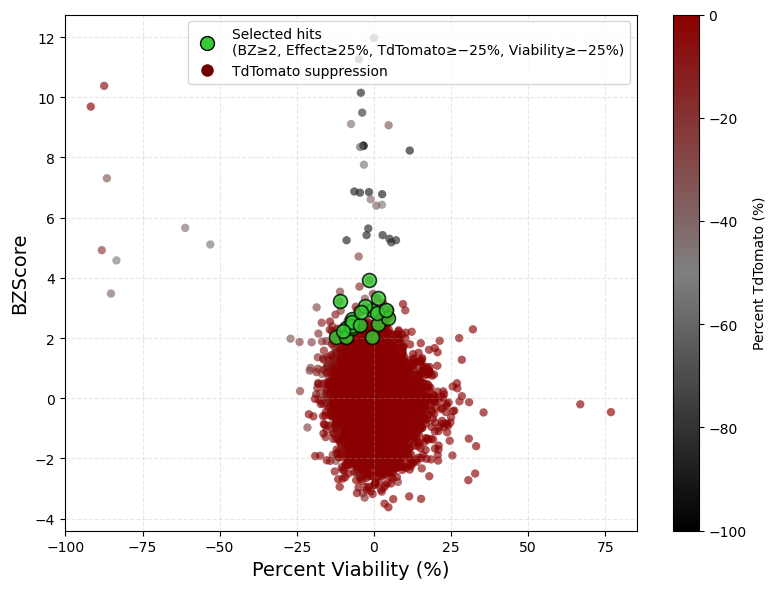

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8, 6))

# --------------------------------------------------
# Normalization + colormap
# --------------------------------------------------
norm = mcolors.Normalize(vmin=-100, vmax=0)


td_cmap = LinearSegmentedColormap.from_list(
    "TdTomatoRich",
    [ "#000000", "#7f7f7f", "darkred"]
)

# --------------------------------------------------
# Background scatter
# --------------------------------------------------
ax.scatter(
    sub_df["Viability"],
    sub_df["BZScore"],
    c=sub_df["tdTomato_Diff"],
    cmap=td_cmap,
    norm=norm,
    alpha=0.65,
    linewidths=0,
)

# --------------------------------------------------
# Selected hits (GREEN, dominant)
# --------------------------------------------------
ax.scatter(
    sub_df.loc[mask_hits, "Viability"],
    sub_df.loc[mask_hits, "BZScore"],
    s=100,
    c="limegreen",
    alpha=0.8,
    edgecolors="black",
    linewidths=1.2,
    zorder=5
)

# --------------------------------------------------
# Formatting
# --------------------------------------------------
ax.set_xlabel("Percent Viability (%)", fontsize=14)
ax.set_ylabel("BZScore", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.3)

# --------------------------------------------------
# Legend
# --------------------------------------------------
legend_elements = [
    Line2D([0], [0], marker="o", color="w",
           label="Selected hits\n(BZ≥2, Effect≥25%, TdTomato≥−25%, Viability≥−25%)",
           markerfacecolor="limegreen",
           markeredgecolor="black",
           markersize=10),
    Line2D([0], [0], marker="o", color="w",
           label="TdTomato suppression",
           markerfacecolor="#6e0000",
           markersize=10),
]

ax.legend(handles=legend_elements, loc="upper right", frameon=True)

# --------------------------------------------------
# Colorbar
# --------------------------------------------------
sm = plt.cm.ScalarMappable(norm=norm, cmap=td_cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Percent TdTomato (%)")

plt.tight_layout()
plt.savefig(
    "BZScore_vs_Viability_TdTomato_Nuanced.png",
    dpi=400,
    bbox_inches="tight"
)
plt.show()


In [99]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
import pandas as pd

# -----------------------------
# Example: your SMILES list
# -----------------------------
smiles_list = df_Effect_tdTomato_Viability["SMILES"].tolist()

# Convert to RDKit molecules
mols = [Chem.MolFromSmiles(s) for s in smiles_list]

# Compute Morgan fingerprints (radius=2, nBits=2048)
fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=2048) for m in mols]

# -----------------------------
# Pairwise Tanimoto similarity matrix
# -----------------------------
n = len(fps)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        sim_matrix[i, j] = sim
        sim_matrix[j, i] = sim

# Convert to DataFrame for readability
sim_df = pd.DataFrame(sim_matrix, columns=smiles_list, index=smiles_list)

sim_df.head()


[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerator
[19:12:00] DEPRECATION WARNING: please use MorganGenerat

,S1C2=C(N3CCN(CCCC4=CN(C)N=C4)CC3)N=CN=C2C=C1,BrC1=C(OC)C=CC([C@@H](NCC2=NOC(C)=N2)C)=C1,S1C(C)=NC(CN2CCC(CNC(=O)NC3=CC=CC=C3)CC2)=C1,N1=C(N2CCCCC2)C(CNCC2=C(N(C)C)N(C)N=C2C)=CC=C1,O=C(N(CC1=CN=CC=C1)C)C1=CC(OC)=C(OC2CCCC2)C=C1,O=C(N1CC(N2CCCC2)CCCC1)NC(CC1=CC=C(O)C=C1)C,N1=C(C(C)C)C(CN[C@H](CN2C=NC=C2)C)=C(N(C)C)N1C,S1C(N(C(=O)C)C)=NC(CN2[C@H](C3=C(C)N(C)N=C3C)CCC2)=C1,FC(F)(F)CN1CCN(CC(=O)NC2=CC(OC)=CC=C2)CCC1,O=C(N(CCN(C1CCN(C)CC1)C)C)NC1=CC(C(C)C)=CC=C1,S(=O)(=O)(N1CCOCC1)CCNCC1=C2OCCOC2=CC=C1,O=C(NC1=CC(C)=NN1C)CN1[C@@H](COC2=CC=CC=C2)CCC1,FC1=C(OC)C=CC(CNC2=CN(CC(=O)NCCN(C)C)N=C2)=C1,ClC1=CC(C2=CN=C(CN3CCN(C(=O)COC)CC3)O2)=CC=C1,O=C(N([C@H](C1=CC=NC=C1)CC)C)NCC1=NC=C(C)C(OC)=C1C,O=C(N1C2=C(C=CC=C2)C[C@H](N2N=CC=C2)C1)C1=C(C)N(CC)N=C1C,O=C(NC1=C(C)C=CC(OC)=C1)NC[C@@H](CN1CCN(CC)CC1)C,S1C=NC(CN2CCN(C(=O)CN3N=C(C)C=C3C)CCC2)=C1,O=C(N1CCCCC1)CCNC(=O)CC1=COC2=C1C=CC(OC)=C2,O=C(NCCCN1[C@H](C(=O)N(C)C)CCC1)C1=NNC2=C1C=CC=C2
S1C2=C(N3CCN(CCCC4=CN(C)N=C4)CC3)N=CN=C2C=C1,1.000000,0.084337,0.156627,0.172840,0.113636,0.109756,0.096386,0.123596,0.134146,0.130952,0.084337,0.139535,0.134831,0.166667,0.102273,0.098901,0.144578,0.156627,0.101124,0.134831
BrC1=C(OC)C=CC([C@@H](NCC2=NOC(C)=N2)C)=C1,0.084337,1.000000,0.108434,0.123457,0.175000,0.101266,0.144737,0.090909,0.126582,0.137500,0.088608,0.119048,0.197531,0.119048,0.192308,0.078652,0.166667,0.095238,0.146341,0.102273
S1C(C)=NC(CN2CCC(CNC(=O)NC3=CC=CC=C3)CC2)=C1,0.156627,0.108434,1.000000,0.141176,0.149425,0.177215,0.081395,0.291139,0.217949,0.227848,0.135802,0.250000,0.157303,0.204819,0.137931,0.172414,0.227848,0.240506,0.149425,0.211765
N1=C(N2CCCCC2)C(CNCC2=C(N(C)C)N(C)N=C2C)=CC=C1,0.172840,0.123457,0.141176,1.000000,0.164706,0.135802,0.295775,0.202381,0.132530,0.156627,0.181818,0.207317,0.120879,0.125000,0.152941,0.147727,0.116279,0.154762,0.164706,0.172414
O=C(N(CC1=CN=CC=C1)C)C1=CC(OC)=C(OC2CCCC2)C=C1,0.113636,0.175000,0.149425,0.164706,1.000000,0.172840,0.104651,0.168539,0.182927,0.192771,0.080460,0.186047,0.250000,0.172414,0.202381,0.142857,0.164706,0.123596,0.159091,0.220930


[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerator
[19:12:10] DEPRECATION WARNING: please use MorganGenerat

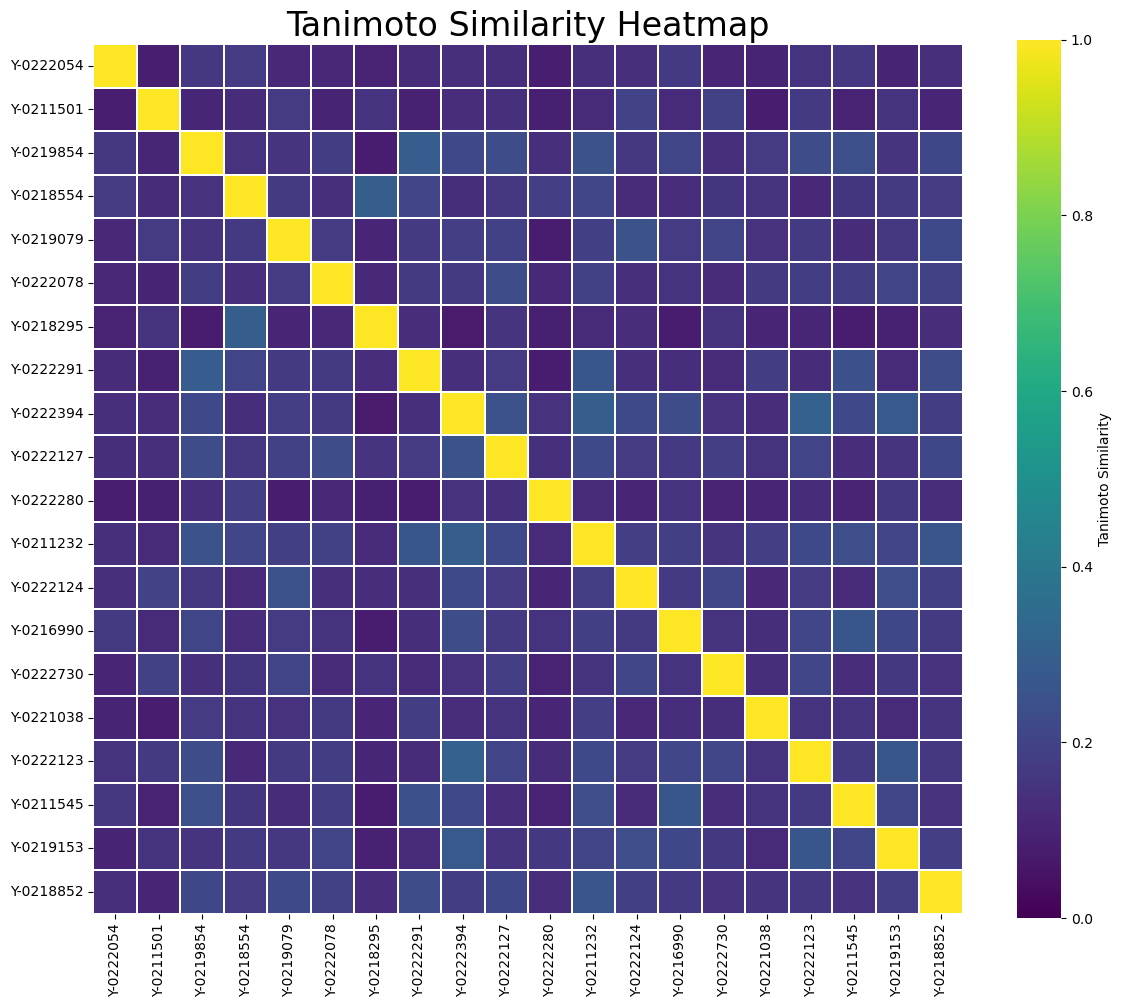

In [100]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load SMILES list
# -----------------------------
smiles_list = df_Effect_tdTomato_Viability["SMILES"].tolist()
mols = [Chem.MolFromSmiles(s) for s in smiles_list]

# -----------------------------
# 2. Morgan fingerprints
# -----------------------------
fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=2048) for m in mols]

# -----------------------------
# 3. Pairwise Tanimoto similarity matrix
# -----------------------------
n = len(fps)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        sim_matrix[i, j] = sim
        sim_matrix[j, i] = sim

# Put into DataFrame
names = df_Effect_tdTomato_Viability["Reference"].tolist()

sim_df = pd.DataFrame(sim_matrix, index=names, columns=names)

# -----------------------------
# 4. Heatmap
# -----------------------------
plt.figure(figsize=(12, 10))

sns.heatmap(
    sim_df,
    cmap="viridis",         # 'magma', 'plasma', 'coolwarm', etc.
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"label": "Tanimoto Similarity"},
)

plt.title("Tanimoto Similarity Heatmap", fontsize=24)
plt.tight_layout()

# Save high-resolution heatmap
plt.savefig("tanimoto_heatmap.png", dpi=400, bbox_inches="tight")
plt.show()


### Determine clusters of similar compounds ranked by taniomoto:

In [106]:
import networkx as nx

threshold = 0.3

# Build graph
G = nx.Graph()

# Add nodes
for name in names:
    G.add_node(name)

# Add edges for similarity ≥ threshold
for i in range(n):
    for j in range(i + 1, n):
        if sim_matrix[i, j] >= threshold:
            G.add_edge(names[i], names[j], weight=sim_matrix[i, j])

# Extract clusters (connected components)
clusters = list(nx.connected_components(G))

# Keep only clusters with >1 compound
clusters = [sorted(list(c)) for c in clusters if len(c) > 1]

# Print clusters
print(f"Found {len(clusters)} similarity clusters (Tanimoto ≥ {threshold}):\n")

for i, cluster in enumerate(clusters, 1):
    print(f"Cluster {i} ({len(cluster)} compounds):")
    for name in cluster:

        print(f"  - {name}")
    print()




Found 1 similarity clusters (Tanimoto ≥ 0.3):

Cluster 1 (2 compounds):
  - Y-0222123
  - Y-0222394

